# **Projekt Analiza Danych** #
**Imię i nazwisko:** Kamil Batorowicz   
**Numer indeksu:** 251124   
**Temat:** Analiza zbioru Liver Disorders (BUPA)

---
## 1. Opis problemu ##

**a) Opis zbioru danych**   
Zbiór danych **BUPA Liver Disorders** pochodzi z repozytorium UCI Machine Learning. Został stworzony przez BUPA Medical Research Ltd. Dane zawierają wyniki badań krwi mężczyzn, u których podejrzewano zaburzenia wątroby mogące wynikać z nadmiernego spożycia alkoholu.

Zbiór składa się z 345 instancji i 7 atrybutów. Celem jest klasyfikacja zmiennej `selector` (oznaczającej podział na dwie grupy diagnostyczne) na podstawie pozostałych cech.

**Cechy (zmienne):**
1. `mcv`: średnia objętość krwinki (mean corpuscular volume)
2. `alkphos`: fosfataza alkaliczna
3. `sgpt`: aminotransferaza alaninowa
4. `sgot`: aminotransferaza asparaginianowa
5. `gammagt`: gamma-glutamylotranspeptydaza
6. `drinks`: liczba półpintowych napojów alkoholowych wypijanych dziennie
7. `selector`: zmienna decyzyjna (klasa 1 lub 2)

**Źródło danych:** https://archive.ics.uci.edu/dataset/60/liver+disorders

In [1]:
# import bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
# nazwy kolumn na podstawie bupa.name
column_names = ['mcv', 'alkphos', 'sgpt', 'sgot', 'gammagt', 'drinks', 'selector']

try:
    df = pd.read_csv('bupa.data', header=None, names=column_names)
    print("Zbiór danych wczytany")
except FileNotFoundError:
    print("Błąd")

df.head()

Zbiór danych wczytany


,mcv,alkphos,sgpt,sgot,gammagt,drinks,selector
0,85,92,45,27,31,0.0,1
1,85,64,59,32,23,0.0,2
2,86,54,33,16,54,0.0,2
3,91,78,34,24,36,0.0,2
4,87,70,12,28,10,0.0,2


---
## 2. Opis danych ##

In [3]:
print(f"Rozmiar zbioru (wiersze, kolumny): {df.shape}")
display(df.describe())

print("Rozkład zmiennej decyzyjnej")
# zbalansowane
print(df['selector'].value_counts())

Rozmiar zbioru (wiersze, kolumny): (345, 7)


,mcv,alkphos,sgpt,sgot,gammagt,drinks,selector
count,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000
mean,90.159420,69.869565,30.405797,24.643478,38.284058,3.455072,1.579710
std,4.448096,18.347670,19.512309,10.064494,39.254616,3.337835,0.494322
min,65.000000,23.000000,4.000000,5.000000,5.000000,0.000000,1.000000
25%,87.000000,57.000000,19.000000,19.000000,15.000000,0.500000,1.000000
50%,90.000000,67.000000,26.000000,23.000000,25.000000,3.000000,2.000000
75%,93.000000,80.000000,34.000000,27.000000,46.000000,6.000000,2.000000
max,103.000000,138.000000,155.000000,82.000000,297.000000,20.000000,2.000000


Rozkład zmiennej decyzyjnej
selector
2    200
1    145
Name: count, dtype: int64


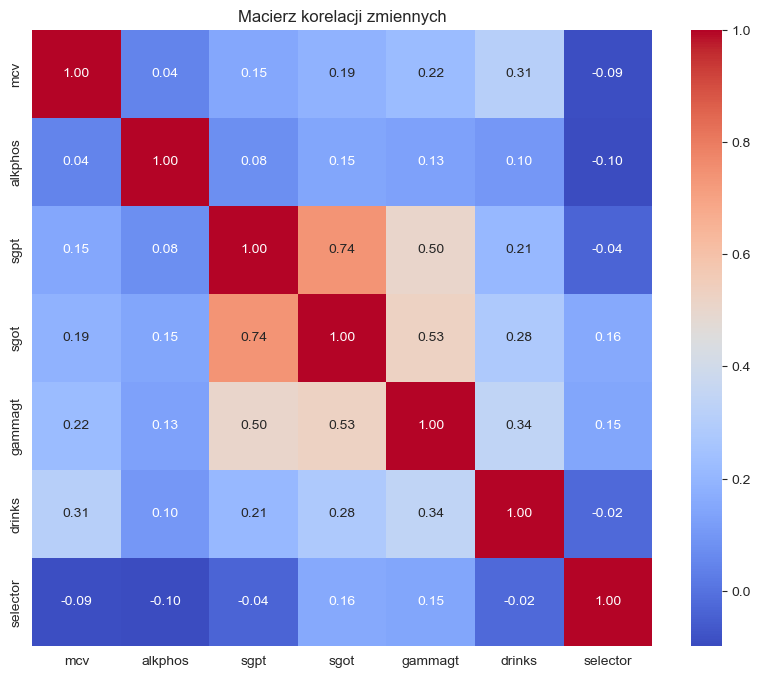

In [4]:
# macierz korelacji
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji zmiennych')
plt.show()

**INTERPRETACJA MACIERZY KORELACJI**
* Najsilniejszą zależność widać pomiędzy `sgot` i `sgpt`, wynoszącą 0.74.
* Umiarkowana zależność jest też widoczna pomiędzy `sgpt` i `gammagt` (0.53) oraz `sgpt` i `gammagt` (0.50).   

Macierz potwierdza logiczne powiązania biologiczne między wynikami badań, ale wskazuje też na trudność zadania klasyfikacji ze względu na brak jednej, silnie skorelowanej z wynikiem cechy.

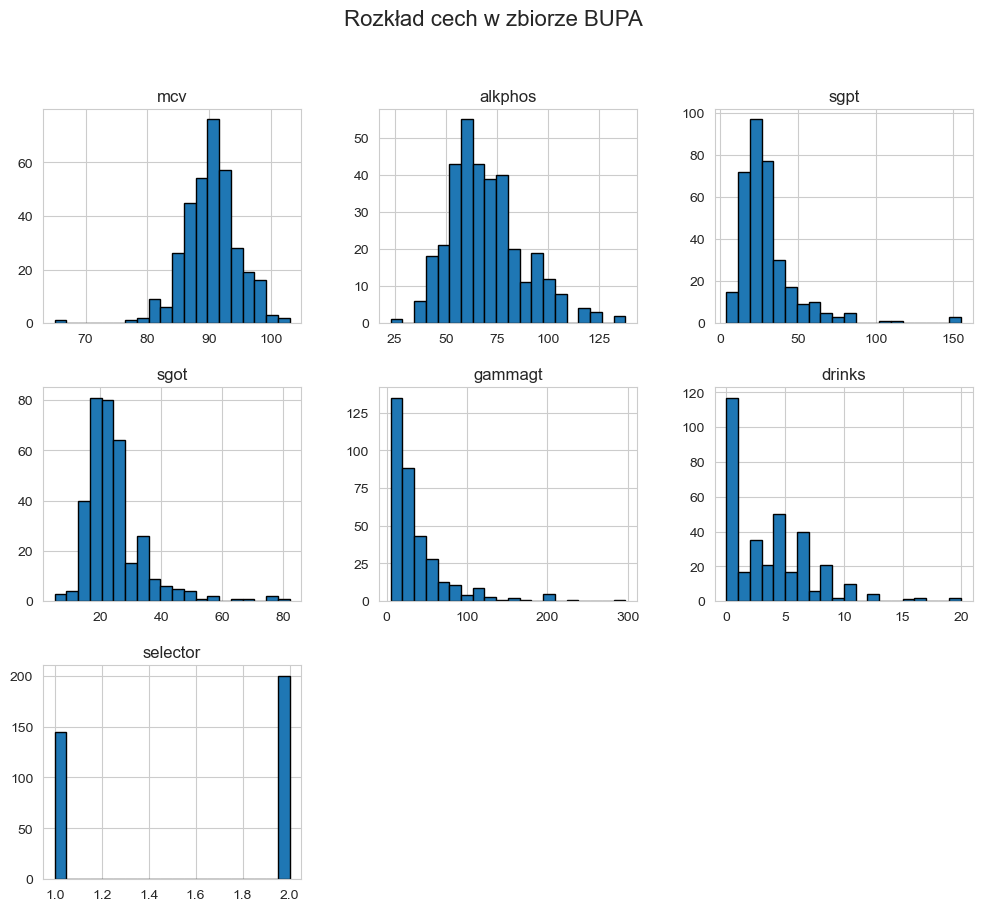

In [5]:
# histogramy
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle('Rozkład cech w zbiorze BUPA', fontsize=16)
plt.show()

**INTERPRETACJA CECH**
* Skośność rozkładów (asymetria prawostronna) - cechy: `sgpt`, `sgot` oraz `gammagt` mają wyraźny rozkład prawostronnie skośny (log-normalny). Większość pacjentów ma niskie (normatywne) wyniki, a tylko nieliczna grupa posiada bardzo wysokie wartości. Potwierdza to konieczność standaryzacji (StandardScaler).
* Rozkład `mcv` i `alkphos` mają rozkłady zbliżone do normalnego (krzywa dzwonowa), co jest dobre dla większości algorytmów statystycznych.
* Nierównomierność klas `selector`: klasy nie są idealnie zbalansowane (klasa 2 jest liczniejsza niż klasa 1).


---
## 3. Przygotowanie danych

**a) Czyszczenie danych**   
Zgodnie z dokumentacją zbioru, dane nie zawierają brakujących wartości (NaN). Jednakże, dołączony plik `noteDuplicates.txt` wskazuje na istnienie zduplikowanych wpisów, które mogą zaburzyć proces uczenia. Należy je usunąć.

**b) Wybór cech**   
Do modelowania wybrane zostaną wszystkie cechy medyczne oraz informacja o spożyciu alkoholu. Zmienną celową jest `selector`.

**c) Przekształcenia**   
Zostanie zastosowana standaryzacja (skalowanie) danych, co jest wymagane dla algorytmów opartych na odległości (np. KNN).

Liczba braków danych (NaN): 0
Liczba zduplikowanych wierszy znalezionych w zbiorze: 0
Nowy rozmiar zbioru: (341, 7)


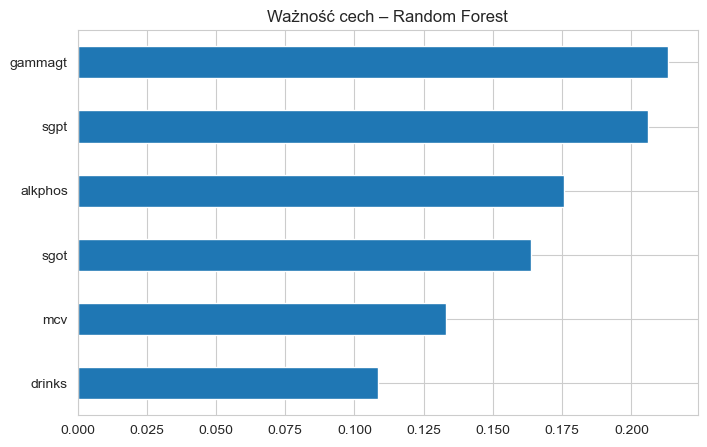

gammagt    0.213255
sgpt       0.205893
alkphos    0.175498
sgot       0.163590
mcv        0.133094
drinks     0.108669
dtype: float64


In [9]:
# 3a) CZYSZCZENIE DANYCH

# braki
print("Liczba braków danych (NaN):", df.isnull().sum().sum())

# duplikaty (wskazane w noteDuplicates.txt)
duplicates = df.duplicated().sum()
print(f"Liczba zduplikowanych wierszy znalezionych w zbiorze: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplikaty zostały usunięte.")
    
df = df.reset_index(drop=True)
print(f"Nowy rozmiar zbioru: {df.shape}")

# -------------------------------------------------------------------------------------------------------------
# 3b) wybór cech

X = df.drop('selector', axis=1)
y = df['selector']

# ważność cech random forest
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Ważność cech – Random Forest")
plt.show()
print(importances.sort_values(ascending=False))

**OBSERWACJE WAŻNOŚCI CECH**
* Największy wpływ na decyzje modelu mają enzymy `gammagt` i `sgpt` (łącznie odpowiadają za ponad 40% wagi)
* Parametry `alkphos`, `sgot` oraz `mcv` wnoszą umiarkowany, lecz stabilny wkład w predykcję.
* Zmienna `drinks` ma najniższą wagę (~11%), prawdopodobnie dlatego, że informacja o spożyciu alkoholu jest już pośrednio zawarta w podwyższonych wynikach enzymatycznych.

POZOSTAWIAM WSZYSTKIE CECHY, NIE MA CECH NIEISTOTNYCH (BLISKICH 0).

In [11]:
# 3c) przekształcenia danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nPodgląd danych po skalowaniu:")
display(X_scaled.head())


Podgląd danych po skalowaniu:


,mcv,alkphos,sgpt,sgot,gammagt,drinks
0,-1.151688,1.201227,0.740728,0.231394,-0.187950,-1.028276
1,-1.151688,-0.320104,1.456566,0.726410,-0.391091,-1.028276
2,-0.926759,-0.863436,0.127153,-0.857639,0.396080,-1.028276
3,0.197885,0.440561,0.178285,-0.065615,-0.060987,-1.028276
4,-0.701830,0.005895,-0.946603,0.330397,-0.721195,-1.028276


---
## 4. Tworzenie modelu i ocena ##

**a) Podział zbioru**   
Zbiór został podzielony na treningowy (80%) i testowy (20%), aby zweryfikować działanie modelu na nieznanych danych.

**b) Wykorzystane algorytmy i parametry**
1. **Logistic Regression** - model liniowy stosowany jako punkt odniesienia (parametry domyślne).
2. **K-Nearest Neighbors (KNN)** - algorytm k-najbliższych sąsiadów. Ustawiono parametr **k=5** (liczba sąsiadów).
3. **Random Forest** - zespół drzew decyzyjnych. Początkowo ustawiono **100 drzew** (`n_estimators=100`) i domyślną głębokość.

In [12]:
# 4a) PODZIAŁ ZBIORU (Trening: 80%, Test: 20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# modele
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

# -------------------------------------------------------------------------------------------------------------
# 4b i 4c) TRENOWANIE I OCENA

print("WYNIKI MODELI\n")

for name, model in models.items():
    # trenowanie
    model.fit(X_train, y_train)
    
    # predykcja
    y_pred = model.predict(X_test)
    
    # ocena
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"Model: {name}")
    print(f"Dokładność (Accuracy): {acc:.4f}")
    print("-" * 30)
    print("Macierz pomyłek:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 30)
    print("Metryki klasyfikacji:")
    print(classification_report(y_test, y_pred))
    print("=" * 60)

WYNIKI MODELI

Model: Logistic Regression
Dokładność (Accuracy): 0.6957
------------------------------
Macierz pomyłek:
[[13 12]
 [ 9 35]]
------------------------------
Metryki klasyfikacji:
              precision    recall  f1-score   support

           1       0.59      0.52      0.55        25
           2       0.74      0.80      0.77        44

    accuracy                           0.70        69
   macro avg       0.67      0.66      0.66        69
weighted avg       0.69      0.70      0.69        69

Model: KNN (k=5)
Dokładność (Accuracy): 0.5652
------------------------------
Macierz pomyłek:
[[12 13]
 [17 27]]
------------------------------
Metryki klasyfikacji:
              precision    recall  f1-score   support

           1       0.41      0.48      0.44        25
           2       0.68      0.61      0.64        44

    accuracy                           0.57        69
   macro avg       0.54      0.55      0.54        69
weighted avg       0.58      0.57      0.5

---
**e) Czynności poprawiające wynik**   
Aby poprawić wynik klasyfikacji, zastosowano metodę **Grid Search** (przeszukiwanie siatki hiperparametrów) dla algorytmu Random Forest.
Optymalizowane parametry to:
* `n_estimators`: liczba drzew (50, 100, 200),
* `max_depth`: maksymalna głębokość drzewa (ograniczenie zapobiegające przeuczeniu),
* `min_samples_leaf`: minimalna liczba próbek w liściu,
* `criterion`: kryterium podziału (Gini lub Entropia).

In [14]:
# 4d) PRZYKŁADOWY WYNIK KLASYFIKACJI (Na podstawie danych z pliku)

# losowy pacjent
losowy_indeks = y_test.sample(1).index[0]

# surowy rekord
pacjent_surowy = X.loc[losowy_indeks]

# pobieramy prawdziwą klasę (diagnozę)
prawdziwa_klasa = y.loc[losowy_indeks]

# przetwarzamy dane dla modelu (skalowanie)
pacjent_do_modelu = scaler.transform(pacjent_surowy.values.reshape(1, -1))

# predykcja modelu
model = models["Random Forest"] 
predykcja = model.predict(pacjent_do_modelu)[0]
prawdopodobienstwo = model.predict_proba(pacjent_do_modelu)[0]

print(f"PACJENT Z PLIKU (Wiersz #{losowy_indeks})")
for cecha, wartosc in pacjent_surowy.items():
    print(f"  * {cecha}: {wartosc}")

print("\nDIAGNOZA:")
print(f"  -> Rzeczywista klasa (z pliku): {prawdziwa_klasa}")
print(f"  -> Decyzja modelu: {predykcja}")
print(f"  -> Pewność: {max(prawdopodobienstwo):.2%}")

if prawdziwa_klasa == predykcja:
    print("\n✅ WYNIK: POPRAWNY")
else:
    print("\n❌ WYNIK: BŁĘDNY")

PACJENT Z PLIKU (Wiersz #25)
  * mcv: 92.0
  * alkphos: 70.0
  * sgpt: 24.0
  * sgot: 13.0
  * gammagt: 26.0
  * drinks: 0.5

2. DIAGNOZA:
  -> Rzeczywista klasa (z pliku): 1
  -> Decyzja modelu: 1
  -> Pewność: 57.00%

✅ WYNIK: POPRAWNY
--------------------------------------------------------

Najlepsze znalezione parametry: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}
Dokładność modelu bazowego: 0.7101
Dokładność po Grid Search: 0.7536
Wynik został poprawiony


In [16]:
# 4e) poprawienie wyniku

# parametry
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# model Grid Search
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# trenujemy
rf_grid.fit(X_train, y_train)

print(f"Najlepsze znalezione parametry: {rf_grid.best_params_}")

best_rf_model = rf_grid.best_estimator_
y_pred_optimized = best_rf_model.predict(X_test)
acc_optimized = accuracy_score(y_test, y_pred_optimized)

print(f"Dokładność modelu bazowego: {results['Random Forest']:.4f}")
print(f"Dokładność po Grid Search: {acc_optimized:.4f}")

if acc_optimized > results['Random Forest']:
    print("Wynik został poprawiony")
elif acc_optimized == results['Random Forest']:
    print("Wynik bez zmian")
else:
    print("Model 'best_estimator' jest optymalny wg walidacji krzyżowej (trening), ale na małym zbiorze testowym wypadł nieco gorzej.")

Najlepsze znalezione parametry: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}
Dokładność modelu bazowego: 0.7101
Dokładność po Grid Search: 0.7536
Wynik został poprawiony


---
## 5. Podsumowanie

**Wnioski z analizy:**

1.  **Ocena algorytmów:**
    * Najlepszym modelem okazał się **Random Forest**, osiągając dokładność na poziomie **ok. 71%**.
    * Najsłabiej wypadł algorytm **KNN (56%)**, co sugeruje, że w wielowymiarowej przestrzeni cech (nawet po normalizacji) klasy nie są od siebie wyraźnie odseparowane geometrycznie.
    * **Logistic Regression (69%)** poradził sobie prawie tak dobrze jak Random Forest, co oznacza, że zależności w danych są w dużej mierze liniowe.

2.  **Macierz pomyłek (Confusion Matrix dla Random Forest):**
    * Model poprawnie zidentyfikował 37 przypadków klasy 2 (True Positives) i 12 przypadków klasy 1.
    * Mylił się częściej przy klasie 1 (13 błędnych wskazań jako klasa 2) niż przy klasie 2. Oznacza to, że model jest "bezpieczniejszy" w wykrywaniu jednej z grup, ale ma tendencję do nadrozpoznawalności drugiej.

3.  **Trudności w poprawie wyniku:**
    * Próba ręcznego tuningu parametrów (sekcja 4e) początkowo pogorszyła wynik (spadek do 65%). Wynika to z faktu, że zbiór danych jest mały (zaledwie ok. 345 wierszy po usunięciu duplikatów). Przy tak małej próbie model łatwo wpada w *overfitting* lub *underfitting* przy nawet drobnych zmianach parametrów.
    * Zastosowanie *Grid Search* pozwoliło na poprawę wyniku o ok. 4 punkty procentowe **(z 71% na 75%)**, co wskazuje na to, że domyślne parametry Random Forest nie były optymalne dla tak małego zbioru danych.

4.  **Podsumowanie ogólne:**
    * Zbiór *BUPA Liver Disorders* jest trudnym zbiorem klasyfikacyjnym. Uzyskany wynik 71% jest satysfakcjonujący i porównywalny z wynikami literaturowymi dla prostych metod uczenia maszynowego na tych danych. Głównym wyzwaniem była obecność duplikatów w danych surowych oraz nieliniowość niektórych zależności.